In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import PowerTransformer

warnings.filterwarnings('ignore')
# 设置中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False


In [2]:
# 读取数据
df = pd.read_excel(
    r'E:\pycharm all files\眼动数据处理\完整眼动数据分析\眼动数据插值处理文件.xlsx')
df

,阶段,AOI转换次数,静态注视熵(SGE),眼跳注视熵(GTE),组别,性别,被试者,天数,文件路径
0,起飞阶段,13.0,1.398246,0.507883,A,女,付瑞晗,1,E:\pycharm all files\眼动数据处理\Data\A\女\付瑞晗\1\1.q...
1,第1次转弯,4.0,0.890165,0.212143,A,女,付瑞晗,1,E:\pycharm all files\眼动数据处理\Data\A\女\付瑞晗\1\2.z...
2,第2次转弯,10.0,0.923579,0.399419,A,女,付瑞晗,1,E:\pycharm all files\眼动数据处理\Data\A\女\付瑞晗\1\3.z...
3,巡航阶段,18.0,1.012136,0.642191,A,女,付瑞晗,1,E:\pycharm all files\眼动数据处理\Data\A\女\付瑞晗\1\4.x...
4,第3次转弯,12.0,1.664170,0.542276,A,女,付瑞晗,1,E:\pycharm all files\眼动数据处理\Data\A\女\付瑞晗\1\5.z...
...,...,...,...,...,...,...,...,...,...
1465,第2次转弯,38.0,1.856486,0.533725,B,男,郭浚杰,7,E:\pycharm all files\眼动数据处理\Data\B\男\郭浚杰\7\3.z...
1466,巡航阶段,38.0,2.609610,0.506751,B,男,郭浚杰,7,E:\pycharm all files\眼动数据处理\Data\B\男\郭浚杰\7\4.x...
1467,第3次转弯,31.0,2.074730,0.374989,B,男,郭浚杰,7,E:\pycharm all files\眼动数据处理\Data\B\男\郭浚杰\7\5.z...
1468,第4次转弯,0.0,0.654472,0.000000,B,男,郭浚杰,7,E:\pycharm all files\眼动数据处理\Data\B\男\郭浚杰\7\6.z...


In [3]:
len(df.被试者.unique())

32

In [4]:
# 去掉最后一列
df = df.iloc[:, :-1]
# 重置列名
df.columns = ['阶段', 'AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)', '组别', '性别', '受试者', '飞行天数']
# 重命名阶段
# df['阶段'] = df['阶段'].replace(['第1次转弯', '第2次转弯', '第3次转弯', '第4次转弯'], '转弯')
df['阶段'] = df['阶段'].replace(['第1次转弯', '第2次转弯', '第3次转弯', '第4次转弯'],
                                ['turn1', 'turn2', 'turn3', 'turn4'])
df['阶段'] = df['阶段'].replace('起飞阶段', '起飞')
df['阶段'] = df['阶段'].replace('降落阶段', '降落')
df['阶段'] = df['阶段'].replace('巡航阶段', '巡航')
# 替换组别名称
df["组别"] = df["组别"].replace({
    "A": "Alcohol",
    "B": "Control"
})

df

,阶段,AOI转换次数,静态注释熵(SGE),眼跳注视熵(GTE),组别,性别,受试者,飞行天数
0,起飞,13.0,1.398246,0.507883,Alcohol,女,付瑞晗,1
1,turn1,4.0,0.890165,0.212143,Alcohol,女,付瑞晗,1
2,turn2,10.0,0.923579,0.399419,Alcohol,女,付瑞晗,1
3,巡航,18.0,1.012136,0.642191,Alcohol,女,付瑞晗,1
4,turn3,12.0,1.664170,0.542276,Alcohol,女,付瑞晗,1
...,...,...,...,...,...,...,...,...
1465,turn2,38.0,1.856486,0.533725,Control,男,郭浚杰,7
1466,巡航,38.0,2.609610,0.506751,Control,男,郭浚杰,7
1467,turn3,31.0,2.074730,0.374989,Control,男,郭浚杰,7
1468,turn4,0.0,0.654472,0.000000,Control,男,郭浚杰,7


In [5]:
# 查看缺失值
print('缺失值个数：', df.isnull().sum().sum())
# 查看异常值
df1 = df[df['AOI转换次数'].isnull()]
df1

缺失值个数： 45


,阶段,AOI转换次数,静态注释熵(SGE),眼跳注视熵(GTE),组别,性别,受试者,飞行天数
285,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,1
292,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,2
299,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,3
306,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,4
313,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,5
320,turn4,NaN,NaN,NaN,Alcohol,男,刘子皓,6
384,降落,NaN,NaN,NaN,Alcohol,男,徐梓军,3
391,降落,NaN,NaN,NaN,Alcohol,男,徐梓军,4
398,降落,NaN,NaN,NaN,Alcohol,男,徐梓军,5
489,降落,NaN,NaN,NaN,Alcohol,男,李嘉文,1


In [6]:
# 删除缺失值
df = df.dropna()
print(df.isnull().sum())

阶段            0
AOI转换次数       0
静态注释熵(SGE)    0
眼跳注视熵(GTE)    0
组别            0
性别            0
受试者           0
飞行天数          0
dtype: int64


In [7]:
df.to_excel(r'眼动数据格式对齐后(四次转弯)文件.xlsx', index=False)

<Figure size 600x400 with 0 Axes>

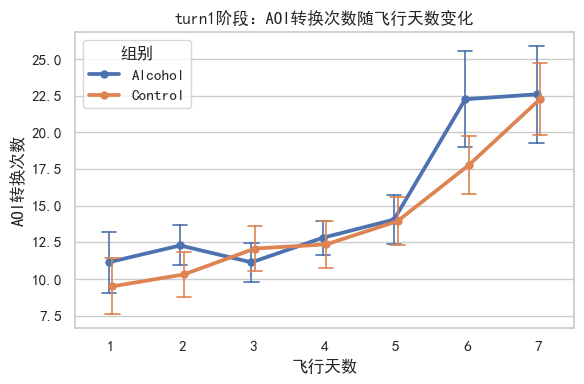

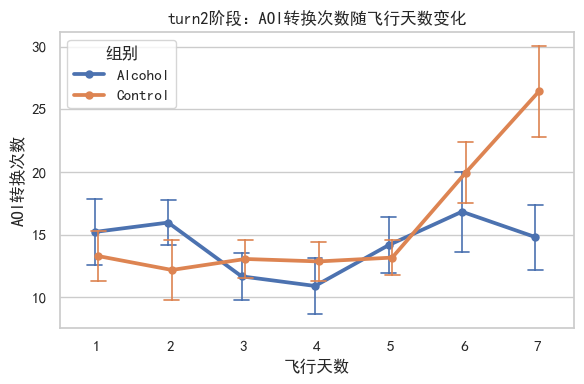

<Figure size 600x400 with 0 Axes>

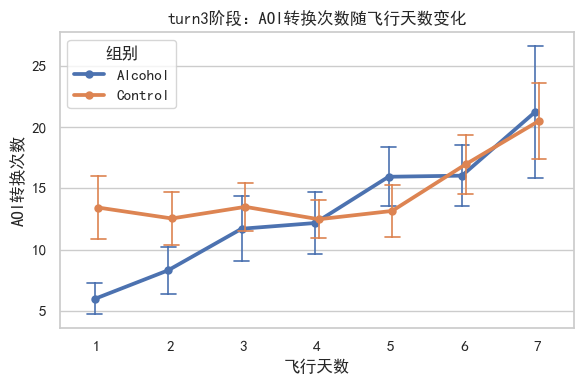

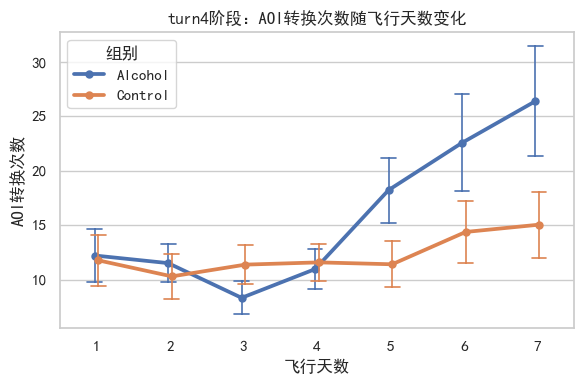

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

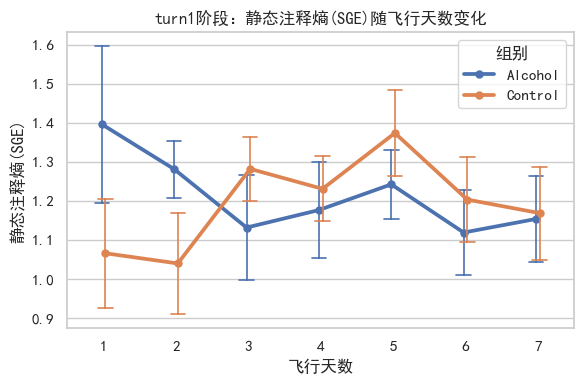

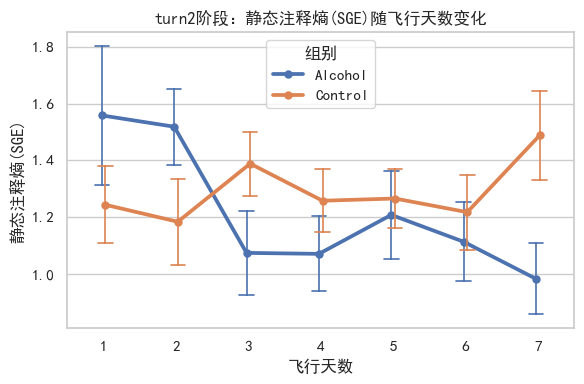

<Figure size 600x400 with 0 Axes>

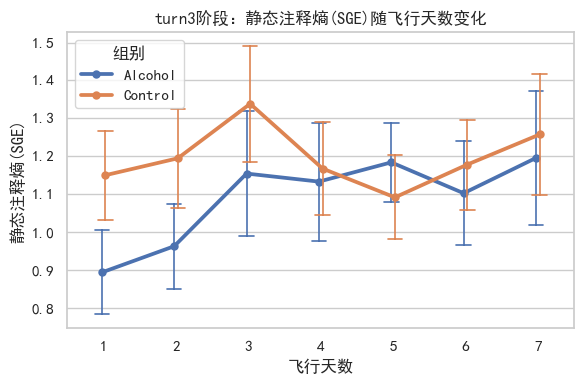

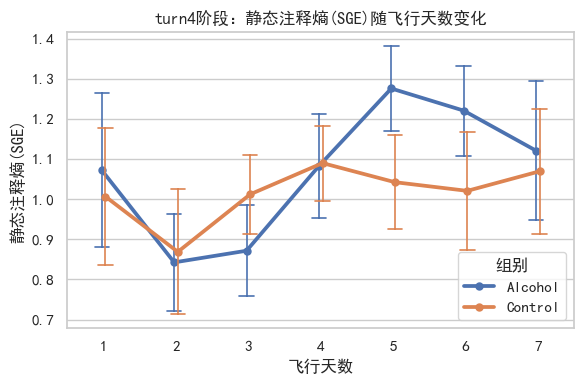

<Figure size 600x400 with 0 Axes>

<Figure size 600x400 with 0 Axes>

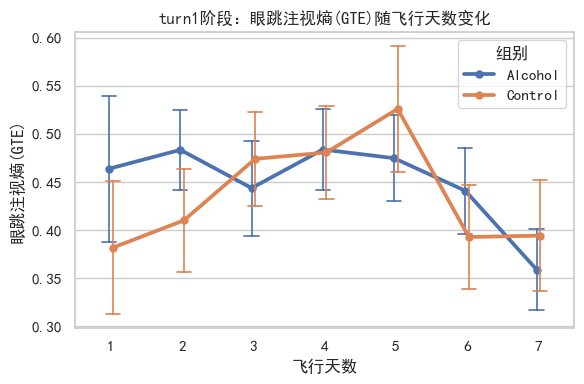

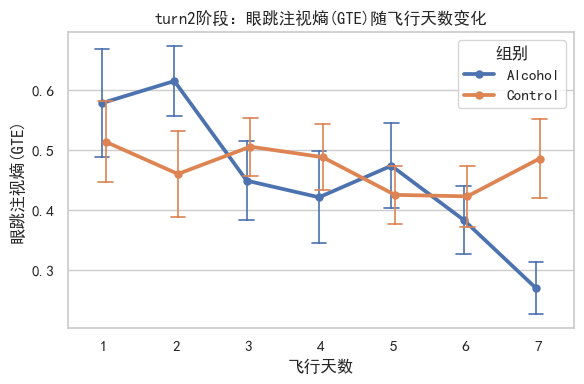

<Figure size 600x400 with 0 Axes>

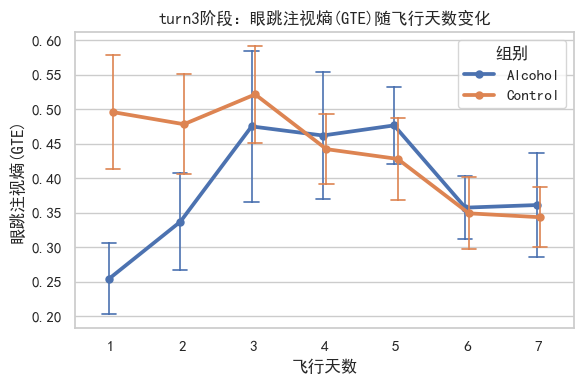

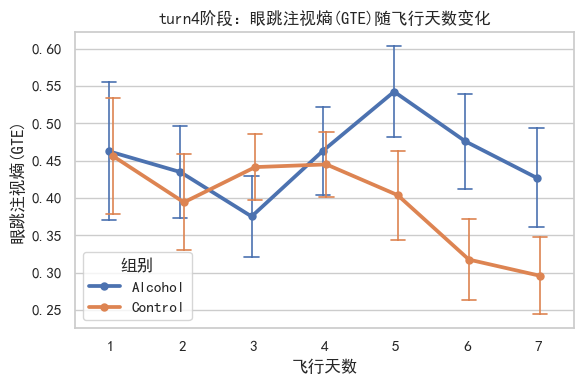

<Figure size 600x400 with 0 Axes>

In [8]:
# 设定绘图风格
sns.set(style="whitegrid", font="SimHei")  # 支持中文显示

# 三个阶段
phases = df["阶段"].unique()
label = 'AOI转换次数'
labels = ['AOI转换次数', '静态注释熵(SGE)', '眼跳注视熵(GTE)']

for label in labels:
    # 建立图表
    for phase in phases:
        plt.figure(figsize=(6, 4))

        if (phase == "降落") | (phase == "起飞") | (phase == "巡航"):
            continue
        # 筛选该阶段数据
        sub_df = df[df["阶段"] == phase]

        sns.pointplot(
            data=sub_df,
            x="飞行天数",
            y=label,
            hue="组别",
            # errorbar=("ci", 95), # 误差线显示 95% 置信区间 # 或 ("se", 1)
            errorbar=("se", 1),  # 画标准误 误差线显示 ±1 标准误
            dodge=True,
            join=True,
            capsize=0.2,  # 控制小横线长度 (相对比例)
            errwidth=1.2,  # 误差线粗细，可调
            markersize=4
        )

        plt.title(f"{phase}阶段：{label}随飞行天数变化")
        plt.xlabel("飞行天数")
        plt.ylabel(label)
        plt.legend(title="组别")
        plt.tight_layout()
        plt.show()
